# ZFIN → ZAPP: the fish reference pipeline

**What this is.** The provenance record for the fish portion of the ZAPP data model:
every field a curator sees, traced to the ZFIN download and transformation that feeds
it, with the breakdown of the data *in our model's terms* and the QC evidence behind
each design decision. It runs the *production* code
(`zapp_atlas.api.services.zfin_lookup`) — nothing here re-implements the pipeline, so
this report cannot drift from what the API actually serves.

**How to re-run.** `just fetch-zfin` (fresh downloads) then `just qc-report`
(renders `notebooks/zfin_ingest_qc.html`). Numbers moving in ways the QC sections
call out are drift alarms, not formalities.

**The principles the pipeline encodes** (established against the live data, 2026-09):

- **The allele (ZDB-ALT) is the atom of fish identity** — one historical alteration
  event, found or new, never computed from a description. Gene and construct are its
  *context* (what it hit / what it carries), never its identity.
- **IDs are pointers** — we store identity (CURIE + symbol) and what the experiment
  asserts (zygosity, background); molecular detail stays at ZFIN/Alliance.
  *Point, never copy.*
- **Symbols are provenance, not biology** — the prefix decodes to a registering
  institution as a display hint; resolution never parses symbols for meaning.
- **Curators never see an identifier field** — they type names; ids attach silently.

In [1]:
from dataclasses import asdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from zapp_atlas.settings import DEFAULT_ZFIN_DATA_DIR as DATA
from zapp_atlas.api.services import zfin_lookup

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.max_rows", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
TEAL = "#2a9d8a"

def read_zfin(name, n=60):
    """Raw ZFIN download: tab-separated, no header, ragged rows (pad to n cols)."""
    return pd.read_csv(DATA / name, sep="\t", header=None, names=range(n),
                       dtype=str, quoting=3)

files = sorted(DATA.glob("*.txt"))
assert files, f"No ZFIN downloads in {DATA} — run `just fetch-zfin` first."
pd.DataFrame([{"file": f.name, "MB": round(f.stat().st_size / 1e6, 1),
               "rows": sum(1 for _ in open(f, encoding="utf-8"))} for f in files])

/Users/ao33/Desktop/ZAPP_DATA_MODEL_FISH_UPDATE/zapp-atlas/server/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,file,MB,rows
0,aliases.txt,14.8,198041
1,features-affected-genes.txt,11.7,59321
2,features.txt,9.8,84316
3,fish_components_fish.txt,15.1,91258
4,genetic_markers.txt,13.6,205620
5,genotype_backgrounds.txt,0.8,12046
6,genotype_features.txt,10.7,54497
7,wildtypes_fish.txt,0.0,32


## The model at a glance

```
Fish                        name (label, never parsed) · fish_zfin_id
└─ Genotype                 genotype_name · genotype_zfin_id   ← iteration-2 resolver
   ├─ mutant_allele[]       MutantAllele: symbol · allele_id · alteration_type ·
   │                          affected_gene_symbol/_id · zygosity ×3
   ├─ transgenic_allele[]   TransgenicAllele: + construct_name/_id
   └─ background            a Genotype with no alterations (the wild-type strain)
└─ Cross (optional)         maternal_line · paternal_line · progeny_selection
```

Everything below is organized around this tree: for each surface a curator touches,
where its values come from, how they are derived, and whether they are **stored** in
the model or **display-only** context.

## Field-by-field: where every control gets its values

In [2]:
pd.DataFrame([
    ["Background dropdown", "genotype.background {genotype_name, genotype_zfin_id}; pure wild-type fish also get fish_zfin_id",
     "wildtypes_fish.txt", "CURIE-ify fish + genotype ids; sorted; form adds 'unknown' → field simply omitted", "stored"],
    ["Allele search box", "— (drives the card below)",
     "features.txt ⋈ features-affected-genes.txt ⋈ vendored prefix registry",
     "in-memory index; ranked exact > prefix > substring, allele > gene > construct", "—"],
    ["Allele card · allele name", "…allele[].allele_symbol", "features.txt (symbol col)", "verbatim", "stored"],
    ["Allele card · allele id chip", "…allele[].allele_id", "features.txt (ZDB-ALT col)", "'ZFIN:' CURIE", "stored"],
    ["Allele card · what it is", "…allele[].alteration_type", "features.txt (SO col) + schema enum meanings",
     "SO → enum (YAML is the source of truth); unmapped keep ZFIN's label for display", "stored (enum)"],
    ["Allele card · gene row", "mutant_allele[].affected_gene_symbol/_id",
     "features-affected-genes.txt", "rows with relationship 'is allele of' only; first distinct gene", "stored"],
    ["Allele card · construct row", "transgenic_allele[].construct_name/_id",
     "features.txt (construct cols)", "aggregated per allele (co-injected lines carry several); first fills the scalar slots", "stored"],
    ["Allele card · made with", "—", "features.txt (mutagen col)", "plain-English gloss (ENU → 'random chemical mutagenesis', …)", "display-only"],
    ["Allele card · institution pill", "—", "vendored line_designations.tsv",
     "longest registered prefix followed by a digit; NOT ZFIN's per-feature Lab of Origin", "display-only"],
    ["Allele card · view on ZFIN", "—", "derived", "https://zfin.org/<bare id> — where molecular detail and Lab of Origin live", "—"],
    ["Zygosity controls (fish + parents)", "…allele[].zygosity / mother_zygosity / father_zygosity",
     "curator assertion — never looked up", "ZygosityEnum; parents default 'unknown' (ZFIN's U); 'wild type' = ZFIN's W", "stored"],
    ["Name field", "fish.name", "auto-built from the pieces", "editable label; fallback identity for unregistered lines; never parsed", "stored"],
    ["Genotype/fish ids for the whole combination", "genotype.genotype_zfin_id · fish.fish_zfin_id",
     "genotype_features.txt + genotype_backgrounds.txt + fish_components_fish.txt + aliases.txt",
     "iteration 2: match the combo, present ranked candidates, never silent-pick", "stored when resolved"],
    ["Gene picker (new-allele form, next)", "mutant_allele[].affected_gene_symbol/_id",
     "genetic_markers.txt", "gene-like marker types (see Gene authority below); search, never free-typed", "stored"],
    ["Cross section (UI not built yet)", "fish.cross {maternal_line, paternal_line, progeny_selection}",
     "curator assertion", "each parent is itself a Genotype; ProgenySelectionEnum", "stored"],
], columns=["curator-facing surface", "model slot", "source", "derivation", "stored?"])

,curator-facing surface,model slot,source,derivation,stored?
0,Background dropdown,"genotype.background {genotype_name, genotype_zfin_id}; pure wild-type fish also get fish_zfin_id",wildtypes_fish.txt,CURIE-ify fish + genotype ids; sorted; form adds 'unknown' → field simply omitted,stored
1,Allele search box,— (drives the card below),features.txt ⋈ features-affected-genes.txt ⋈ vendored prefix registry,"in-memory index; ranked exact > prefix > substring, allele > gene > construct",—
2,Allele card · allele name,…allele[].allele_symbol,features.txt (symbol col),verbatim,stored
3,Allele card · allele id chip,…allele[].allele_id,features.txt (ZDB-ALT col),'ZFIN:' CURIE,stored
4,Allele card · what it is,…allele[].alteration_type,features.txt (SO col) + schema enum meanings,SO → enum (YAML is the source of truth); unmapped keep ZFIN's label for display,stored (enum)
5,Allele card · gene row,mutant_allele[].affected_gene_symbol/_id,features-affected-genes.txt,rows with relationship 'is allele of' only; first distinct gene,stored
6,Allele card · construct row,transgenic_allele[].construct_name/_id,features.txt (construct cols),aggregated per allele (co-injected lines carry several); first fills the scalar slots,stored
7,Allele card · made with,—,features.txt (mutagen col),"plain-English gloss (ENU → 'random chemical mutagenesis', …)",display-only
8,Allele card · institution pill,—,vendored line_designations.tsv,longest registered prefix followed by a digit; NOT ZFIN's per-feature Lab of Origin,display-only
9,Allele card · view on ZFIN,—,derived,https://zfin.org/<bare id> — where molecular detail and Lab of Origin live,—


## Using the production code

`get_index` is the exact call the API serves from: it builds the in-memory index
lazily (about a second) and caches it per data directory.

In [3]:
index = zfin_lookup.get_index(DATA)

alleles = pd.DataFrame([{
    "symbol": row.record.allele_symbol,
    "institution": row.record.institution,
    "is_tg": row.record.is_transgenic,
    "mutagen": row.record.mutagen,
    "n_constructs": len(row.record.constructs),
    "n_genes": len(row.record.affected_genes),
    "alteration": row.record.alteration_type.value if row.record.alteration_type else None,
} for row in index._rows])

print(f"{index.allele_count:,} distinct alleles · {len(index.wildtypes)} wild-type lines")

81,170 distinct alleles · 32 wild-type lines


One search box serves three vocabularies — allele symbol, gene symbol, construct
fragment — so the curator types whatever name they know:

In [4]:
def hits(q, n):
    total, recs = index.search_alleles(q, n)
    return pd.DataFrame([{
        "query": q,
        "symbol": r.allele_symbol,
        "what it is": (f"integration of {' + '.join(c.construct_name for c in r.constructs)}"
                       if r.is_transgenic else
                       (r.alteration_type.value.replace("_", " ") if r.alteration_type
                        else r.alteration_label.lower())
                       + (f" in {r.affected_genes[0].gene_symbol}" if r.affected_genes else "")),
        "made with": r.mutagen or "—",
        "institution": r.institution or "—",
        "allele_id": r.allele_id,
        "matches": total,
    } for r in recs])

pd.concat([hits("fh111", 1), hits("fgf8a", 4), hits("mpeg1:YFP", 3)], ignore_index=True)

,query,symbol,what it is,made with,institution,allele_id,matches
0,fh111,fh111,point mutation in snapc1b,—,Fred Hutchinson Cancer Research Center,ZFIN:ZDB-ALT-160602-14,1
1,fgf8a,fgf8a_unspecified,sequence alteration in fgf8a,—,—,ZFIN:ZDB-ALT-050209-6,38
2,fgf8a,la012336Tg,integration of Tg(nLacz-GTvirus),DNA,University of California Los Angeles,ZFIN:ZDB-ALT-120806-9701,38
3,fgf8a,sa2694,point mutation in fgf8a,ENU,Welcome Trust Sanger Institute,ZFIN:ZDB-ALT-161003-13039,38
4,fgf8a,ti282a,point mutation in fgf8a,ENU,Tübingen (big-screen designation),ZFIN:ZDB-ALT-980203-1091,38
5,mpeg1:YFP,w200Tg,integration of Tg(mpeg1:YFP),DNA,University of Washington,ZFIN:ZDB-ALT-130130-3,1


## From a hit to the data model — no schema change required

A search hit maps field-for-field onto the generated `FishCreate` model. Below, both a
minimal single-mutant fish and the exact double-line payload the prototype form emitted
(point mutation + transgene + AB background) validate against the schema as-is — the
form captures nothing the YAML cannot store.

In [5]:
from zapp_atlas.schema.pydantic_crud import FishCreate

hit = index.search_alleles("fh111", 1)[1][0]
FishCreate.model_validate({"name": "snapc1b^fh111/fh111 (AB)", "genotype": {"mutant_allele": [{
    "allele_symbol": hit.allele_symbol, "allele_id": hit.allele_id,
    "alteration_type": hit.alteration_type.value,
    "affected_gene_symbol": hit.affected_genes[0].gene_symbol,
    "affected_gene_id": hit.affected_genes[0].gene_id,
    "zygosity": "homozygous",
}]}})

form_payload = {  # emitted by fish_form_v1 on 2026-09-04, verbatim
    "name": "fgf21^ct807; Tg(zp3.2:Omo.Igf2-Rre.GFP) (AB)",
    "genotype": {
        "mutant_allele": [{
            "allele_symbol": "ct807", "allele_id": "ZFIN:ZDB-ALT-131122-8",
            "alteration_type": "deletion",
            "affected_gene_symbol": "fgf21", "affected_gene_id": "ZFIN:ZDB-GENE-060623-2",
            "mother_zygosity": "unknown", "father_zygosity": "unknown",
        }],
        "transgenic_allele": [{
            "allele_symbol": "as203Tg", "allele_id": "ZFIN:ZDB-ALT-110505-7",
            "alteration_type": "transgenic_insertion",
            "mother_zygosity": "unknown", "father_zygosity": "unknown",
            "construct_id": "ZFIN:ZDB-TGCONSTRCT-110505-7",
            "construct_name": "Tg(zp3.2:Omo.Igf2-Rre.GFP)",
        }],
        "background": {"genotype_name": "AB", "genotype_zfin_id": "ZFIN:ZDB-GENO-960809-7"},
    },
}
FishCreate.model_validate(form_payload)
print("both payloads validate against the generated FishCreate ✓")

both payloads validate against the generated FishCreate ✓


## Lookup inventory — what can curators actually find?

The searchable universe, broken down in the model's own terms: which card a hit
becomes, and how complete each card arrives.

In [6]:
tg = alleles["is_tg"]
placeholder = alleles["symbol"].str.contains("_unspecified$|_unrecovered$", regex=True)

display(pd.DataFrame([
    ["alleles searchable, total", len(alleles), ""],
    ["→ become a TransgenicAllele card", int(tg.sum()), "features.txt SO = transgenic insertion (or construct present)"],
    ["   · construct name + id attach", int((tg & (alleles.n_constructs > 0)).sum()), "co-injected lines carry 2"],
    ["   · no construct recorded", int((tg & (alleles.n_constructs == 0)).sum()), "card still valid; id points at the record"],
    ["→ become a MutantAllele card", int((~tg).sum()), ""],
    ["   · affected gene attaches", int((~tg & (alleles.n_genes > 0)).sum()), "features-affected-genes.txt, 'is allele of'"],
    ["   · gene unknown", int((~tg & (alleles.n_genes == 0)).sum()), "shown honestly as 'gene unknown'"],
    ["   · gene-level placeholders (_unspecified / _unrecovered)", int(placeholder.sum()),
     "ZFIN's own honest 'know the gene, not the allele' records — scenario ③"],
    ["alteration_type maps to our enum", int(alleles.alteration.notna().sum()), "SO → schema meanings"],
    ["label-only (unmapped SO type)", int(alleles.alteration.isna().sum()), "ZFIN's label shown; id still points at truth"],
    ["wild-type backgrounds in the dropdown", len(index.wildtypes),
     "incl. registered hybrids and ZFIN's 'WT' (strain unspecified); form adds 'unknown' = stored absence"],
], columns=["what", "count", "notes"]))

assert not (placeholder & tg).any(), "placeholders are expected to be mutant-side"
print("placeholder sample:", ", ".join(alleles.loc[placeholder, "symbol"].head(6)))

,what,count,notes
0,"alleles searchable, total",81170,
1,→ become a TransgenicAllele card,28583,features.txt SO = transgenic insertion (or construct present)
2,· construct name + id attach,28293,co-injected lines carry 2
3,· no construct recorded,290,card still valid; id points at the record
4,→ become a MutantAllele card,52587,
5,· affected gene attaches,52145,"features-affected-genes.txt, 'is allele of'"
6,· gene unknown,442,shown honestly as 'gene unknown'
7,· gene-level placeholders (_unspecified / _unrecovered),176,"ZFIN's own honest 'know the gene, not the allele' records — scenario ③"
8,alteration_type maps to our enum,80617,SO → schema meanings
9,label-only (unmapped SO type),553,ZFIN's label shown; id still points at truth


placeholder sample: acvr1l_unspecified, arhgap21b_unrecovered, ascl1a_unspecified, atoh1a_unrecovered, aus_unspecified, barx1_unrecovered


## The enums, demarcated

Which enums the fish model carries, where their *values* are defined, and what fills
them. Values below are read live from the generated code, so this table cannot drift
from the schema.

In [7]:
from zapp_atlas.schema.pydantic_crud import (ProgenySelectionEnum,
                                             SequenceAlterationTypeEnum, ZygosityEnum)

pd.DataFrame([
    ["ZygosityEnum", ", ".join(e.value for e in ZygosityEnum),
     "schema YAML (GENO meanings)",
     "curator assertion, never looked up. ZFIN's identity-string codes correspond: "
     "2=homozygous 1=heterozygous U=unknown W=wild type (distribution below)"],
    ["SequenceAlterationTypeEnum", ", ".join(e.value for e in SequenceAlterationTypeEnum),
     "schema YAML (SO meanings)",
     "auto-filled from features.txt's SO column via the meanings map (coverage below)"],
    ["ProgenySelectionEnum", ", ".join(e.value for e in ProgenySelectionEnum),
     "schema YAML",
     "curator assertion about the cross (genotyped / phenotype-sorted / assumed uniform); no ZFIN source"],
], columns=["enum", "values (live from generated code)", "values defined by", "what fills it"])

,enum,values (live from generated code),values defined by,what fills it
0,ZygosityEnum,"homozygous, heterozygous, unknown, wild_type",schema YAML (GENO meanings),"curator assertion, never looked up. ZFIN's identity-string codes correspond: 2=homozygous 1=hete..."
1,SequenceAlterationTypeEnum,"point_mutation, substitution, deletion, insertion, indel, inversion, duplication, transgenic_ins...",schema YAML (SO meanings),auto-filled from features.txt's SO column via the meanings map (coverage below)
2,ProgenySelectionEnum,"genotyped, phenotype_sorted, assumed_uniform, segregating, unknown",schema YAML,curator assertion about the cross (genotyped / phenotype-sorted / assumed uniform); no ZFIN source


### SequenceAlterationTypeEnum — SO coverage

Mapped from the SO term via the schema enum's own `meaning:` entries, so the YAML
stays the single source of truth. Unmapped SO types are not an error: the record keeps
ZFIN's human-readable label, and the id still points at the full truth. **Watch:** if
the unmapped share grows on a fresh download, ZFIN added a type worth considering.

coverage: 99.3% of alleles map to the enum


,alleles,zfin_label
1,,
SO:0001023,377,Allele with multiple variants
SO:1000029,111,Deficiency
(blank),39,Allele with one mnv
SO:0000199,26,Translocation


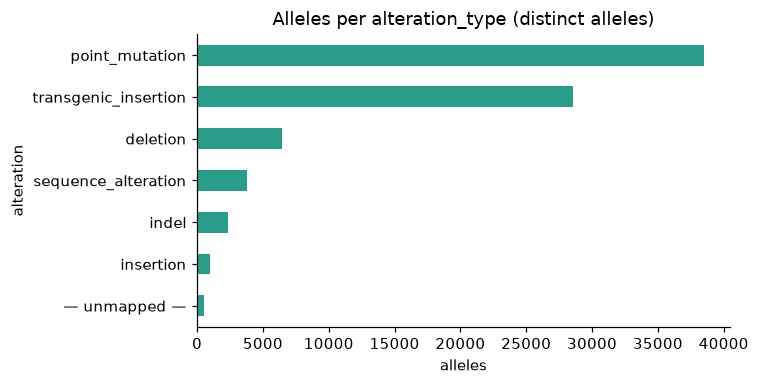

In [8]:
feat = read_zfin("features.txt")
feat = feat[feat[0].str.startswith("ZDB-ALT-", na=False)]

so_map = zfin_lookup._so_to_alteration_type()
unmapped = (feat[~feat[1].isin(so_map)]
            .groupby(feat[1].fillna("(blank)"))
            .agg(alleles=(0, "nunique"), zfin_label=(4, "first"))
            .sort_values("alleles", ascending=False))
print(f"coverage: {alleles['alteration'].notna().mean():.1%} of alleles map to the enum")
display(unmapped)

ax = (alleles["alteration"].fillna("— unmapped —").value_counts().sort_values()
      .plot.barh(color=TEAL, figsize=(7, 3.6)))
ax.set_title("Alleles per alteration_type (distinct alleles)")
ax.set_xlabel("alleles")
plt.tight_layout()

### ZygosityEnum — how ZFIN itself uses the four values

Zygosity is always the curator's assertion, but ZFIN's registered genotypes show the
same vocabulary at work: every allele in `genotype_features.txt` carries a
`[fish, mother, father]` triple. The distribution below (parsed from the identity
strings) is why the form's parents **default to `unknown`** (U dominates real
records) and why **`wild_type` had to enter the enum** (W is routine for parents —
a het fish from a het × wild-type cross was inexpressible without it).

In [9]:
gf = read_zfin("genotype_features.txt")

triples = (gf[2].str.extractall(r"\[([^\[\]]*)\]")[0]
           .str.split(",", expand=True).reindex(columns=range(3)))
triples.columns = ["fish", "mother", "father"]
CODE = {"2": "homozygous", "1": "heterozygous", "U": "unknown", "W": "wild type"}
dist = pd.DataFrame({who: triples[who].str.strip().map(lambda v: CODE.get(v, f"other ({v})"))
                    .value_counts() for who in triples.columns}).fillna(0).astype(int)
dist.index.name = "zygosity (per allele-in-genotype)"
dist

,fish,mother,father
zygosity (per allele-in-genotype),,,
heterozygous,14256,26707,26985
homozygous,36864,2557,1679
other (C),23,3,1
unknown,44541,66241,66692
wild type,0,176,327


## QC — `features.txt` is not one row per allele

Rows repeat two ways: identically (differing only in trailing reagent columns), and
once per construct — a co-injected line is **one** integration event carrying several
constructs. The pipeline aggregates by allele id; the API returns `constructs` as a
list so nothing is lost; the schema's scalar construct slots take the first.

In [10]:
repeated = feat[0].value_counts().loc[lambda s: s > 1]
coinjected = feat.dropna(subset=[7]).groupby(0)[7].nunique().loc[lambda s: s > 1]

display(pd.DataFrame([
    ["raw ZDB-ALT rows", len(feat)],
    ["distinct alleles (what the index serves)", feat[0].nunique()],
    ["allele ids with repeated rows", len(repeated)],
    ["… of which co-injected (>1 distinct construct)", len(coinjected)],
    ["… of which identical repeats (collapse cleanly)", len(repeated) - len(coinjected)],
], columns=["measure", "count"]))

gz = index.search_alleles("gz13Tg", 1)[1][0]
print("example — gz13Tg carries:", [c.construct_name for c in gz.constructs])

,measure,count
0,raw ZDB-ALT rows,84316
1,distinct alleles (what the index serves),81170
2,allele ids with repeated rows,1755
3,… of which co-injected (>1 distinct construct),80
4,… of which identical repeats (collapse cleanly),1675


example — gz13Tg carries: ['Tg2(krt4:GFP)', 'Tg2(mylpfa:RFP)']


## QC — affected genes: why the gene slots are scalar

Only the `is allele of` relationship links a feature to the gene it damages — the
other relationship values are curation bookkeeping and are excluded. Multi-gene
alleles are vanishingly rare, so `affected_gene_symbol`/`_id` stay scalar slots; the
two exceptions are listed for honesty.

In [11]:
ag = read_zfin("features-affected-genes.txt")
display(ag[6].value_counts().rename_axis("relationship").reset_index(name="rows"))

ok = ag[ag[6] == "is allele of"]
genes_per = ok.groupby(0)[4].nunique()
display(genes_per.value_counts().sort_index()
        .rename_axis("distinct genes per allele").reset_index(name="alleles"))

freaks = genes_per.loc[lambda s: s > 1].index
ok[ok[0].isin(freaks)][[0, 2, 3, 4]].rename(
    columns={0: "allele_id", 2: "symbol", 3: "gene", 4: "gene_id"})

,relationship,rows
0,is allele of,59020
1,markers missing,265
2,markers moved,36


,distinct genes per allele,alleles
0,1,59015
1,2,1
2,3,1


,allele_id,symbol,gene,gene_id
54099,ZDB-ALT-221107-1,uab427,nsd2,ZDB-GENE-030131-2581
54100,ZDB-ALT-221107-1,uab427,letm1,ZDB-GENE-050522-154
54625,ZDB-ALT-191227-7,upo351,en.boxc2.sgca,ZDB-ENHANCER-191120-8
54626,ZDB-ALT-191227-7,upo351,en.boxc3.sgca,ZDB-ENHANCER-191120-9
54627,ZDB-ALT-191227-7,upo351,en.boxb2.sgca,ZDB-ENHANCER-191120-6


## QC — institution (display-only provenance)

Derived from the symbol's registered naming prefix (vendored registry, longest prefix
followed by a digit). **Deliberately not called "lab" and deliberately not stored**:
ZFIN's per-feature *Lab of Origin* is curated separately and can differ — e.g.
`la012336Tg` is prefix-registered to UCLA but originated in the Burgess & Lin Lab.
That field exists only on the record page (no bulk download), which is why every
surface links to ZFIN. The 1996 Tübingen screen's two-letter codes predate the
registry and get a named fallback.

institution resolved for 98.6% of alleles (1,276 via the Tübingen legacy fallback)
unresolved sample: acvr1l_unspecified, arhgap21b_unrecovered, ascl1a_unspecified, atoh1a_unrecovered, aus_unspecified, barx1_unrecovered


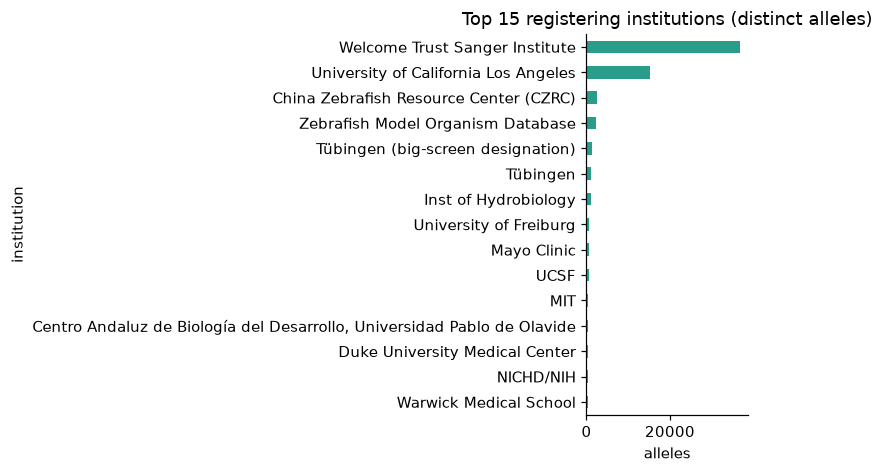

In [12]:
resolved = alleles["institution"].notna()
tueb = (alleles["institution"] == "Tübingen (big-screen designation)").sum()
print(f"institution resolved for {resolved.mean():.1%} of alleles "
      f"({tueb:,} via the Tübingen legacy fallback)")
print("unresolved sample:", ", ".join(alleles.loc[~resolved, "symbol"].head(6)))

ax = (alleles["institution"].value_counts().head(15).sort_values()
      .plot.barh(color=TEAL, figsize=(7, 4.4)))
ax.set_title("Top 15 registering institutions (distinct alleles)")
ax.set_xlabel("alleles")
plt.tight_layout()

## QC — "made with" (display-only gloss)

ZFIN's mutagen column names the *agent* that caused the allele (the cause, never the
identity). Raw values are geneticist shorthand, so the UI glosses them; the mapping is
data, documented here, and nothing is stored. **Watch:** a new raw value on a fresh
download needs a gloss.

In [13]:
GLOSS = {
    "ENU": "ENU (random chemical mutagenesis)", "DNA": "DNA injection (transgenesis)",
    "CRISPR": "CRISPR (targeted gene editing)", "TALEN": "TALEN (targeted gene editing)",
    "DNA and CRISPR": "DNA + CRISPR (targeted knock-in)",
    "DNA and TALEN": "DNA + TALEN (targeted knock-in)",
    "zinc finger nuclease": "zinc-finger nuclease (targeted gene editing)",
    "spontaneous": "spontaneous (arose naturally)", "g-rays": "gamma irradiation",
    "TMP": "TMP (chemical mutagenesis)", "EMS": "EMS (chemical mutagenesis)",
}
(alleles["mutagen"].fillna("(not specified)").value_counts()
 .rename_axis("raw value").reset_index(name="alleles")
 .assign(shown_to_curators=lambda d: d["raw value"].map(GLOSS).fillna("—")))

,raw value,alleles,shown_to_curators
0,ENU,41353,ENU (random chemical mutagenesis)
1,DNA,27831,DNA injection (transgenesis)
2,CRISPR,8699,CRISPR (targeted gene editing)
3,(not specified),1446,—
4,TALEN,1069,TALEN (targeted gene editing)
5,DNA and CRISPR,370,DNA + CRISPR (targeted knock-in)
6,zinc finger nuclease,199,zinc-finger nuclease (targeted gene editing)
7,spontaneous,92,spontaneous (arose naturally)
8,g-rays,87,gamma irradiation
9,DNA and TALEN,18,DNA + TALEN (targeted knock-in)


## QC — the background dropdown, in full

The complete picklist, ids and all — including registered hybrids (AB/TU, WIK/AB…)
and ZFIN's own `WT` ("wild type, strain unspecified"). The form additionally offers
**unknown**, stored as *absence*: every fish has some background, so an omitted one
unambiguously means "not recorded" and no record is ever guessed.

In [14]:
pd.DataFrame([asdict(w) for w in index.wildtypes])

,name,abbreviation,fish_id,genotype_id
0,AB,AB,ZFIN:ZDB-FISH-150901-27842,ZFIN:ZDB-GENO-960809-7
1,AB/C32,AB/C32,ZFIN:ZDB-FISH-150901-19012,ZFIN:ZDB-GENO-070425-3
2,AB/EKW,AB/EKW,ZFIN:ZDB-FISH-150901-18519,ZFIN:ZDB-GENO-091223-1
3,AB/TL,AB/TL,ZFIN:ZDB-FISH-150901-29235,ZFIN:ZDB-GENO-031202-1
4,AB/TU,AB/TU,ZFIN:ZDB-FISH-150901-29084,ZFIN:ZDB-GENO-010924-10
5,ABO,ABO,ZFIN:ZDB-FISH-181106-1,ZFIN:ZDB-GENO-181106-1
6,C32,C32,ZFIN:ZDB-FISH-150901-28222,ZFIN:ZDB-GENO-030501-1
7,Cooch Behar,CB,ZFIN:ZDB-FISH-180717-1,ZFIN:ZDB-GENO-180717-1
8,DAR,DAR,ZFIN:ZDB-FISH-150901-28033,ZFIN:ZDB-GENO-960809-13
9,EKW,EKW,ZFIN:ZDB-FISH-150901-29731,ZFIN:ZDB-GENO-990520-2


## Gene authority (for the new-allele scenario)

When a biologist reports a **brand-new** allele, the one thing that must still resolve
is the gene they altered. **ZFIN is the official nomenclature authority for zebrafish
genes** (it assigns the symbols), and `genetic_markers.txt` carries every marker it
tracks. Two consequences:

- The new-allele form's gene field is a **search over these records** (same pattern as
  the allele search) — genes are never free-typed into existence.
- Genes stay **data, not schema**: 36k symbols do not belong in a YAML enum. The schema
  keeps exactly what it has — a CURIE slot and a symbol slot.

Renames are ZFIN's problem, solved: symbols are current-as-of-download, and old names
live in `aliases.txt` (plus `zdb_history.txt` for retired ids) — the same alias
machinery the resolver will use for nicknames like *casper*.

The referential check below is the load-bearing QC — and it produced this report's
first real catch: **157 ids referenced by real alleles are gene-like types other than
plain `GENE`** (miRNA genes, lincRNA genes, pseudogenes, enhancers), all present in
the marker file. Alleles damage those too, so the picker's universe is the
**gene-like set**, against which integrity is exactly 100%.

In [15]:
mk = read_zfin("genetic_markers.txt")
display(mk[3].value_counts().head(8).rename_axis("marker type").reset_index(name="records"))

GENE_LIKE = {"GENE", "GENEP", "LINCRNAG", "LNCRNAG", "MIRNAG", "NCRNAG", "SNORNAG",
             "ENHANCER", "NCCR"}
genes = mk[mk[3].isin(GENE_LIKE)]
referenced = pd.Series(ok[4].dropna().unique())
strict = referenced.isin(set(mk.loc[mk[3] == "GENE", 0])).mean()
broad = referenced.isin(set(genes[0])).mean()
print(f"{(mk[3] == 'GENE').sum():,} GENE records; {len(genes):,} gene-like records in total")
print(f"referential integrity vs GENE only:          {strict:.2%}")
print(f"referential integrity vs gene-like universe: {broad:.2%}  <- the picker's universe")

types = mk.set_index(0)[3]
(referenced[~referenced.isin(set(mk.loc[mk[3] == "GENE", 0]))].map(types)
 .value_counts().rename_axis("non-GENE marker types alleles actually hit")
 .reset_index(name="referenced ids"))

,marker type,records
0,TSCRIPT,58948
1,GENE,36049
2,CRISPR,18520
3,EST,17537
4,CDNA,17328
5,BAC,12065
6,MRPHLNO,12027
7,TGCONSTRCT,8385


36,049 GENE records; 38,347 gene-like records in total
referential integrity vs GENE only:          99.23%
referential integrity vs gene-like universe: 100.00%  <- the picker's universe


,non-GENE marker types alleles actually hit,referenced ids
0,LINCRNAG,62
1,MIRNAG,45
2,ENHANCER,20
3,GENEP,19
4,LNCRNAG,4
5,NCRNAG,4
6,SNORNAG,2
7,NCCR,1


## Resolver inputs (iteration 2 preview)

`genotype_features.txt` is the registry of allele *combinations*: one row per
(genotype, allele) with the zygosity triple in the identity string. The
allele-set-size distribution shows double/triple mutants are ordinary, and the
ambiguity demo is why the resolver must present **ranked candidates, never a silent
pick**: one famous allele, several registered genotypes differing only by background.

38,141 allele-carrying genotypes registered at ZFIN


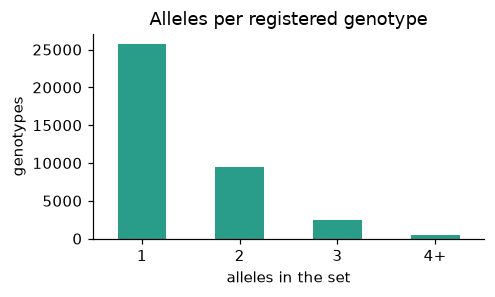

,genotype_id,identity string,background
0,ZDB-GENO-011017-4,"y1Tg[U,U,U]",(none recorded)
1,ZDB-GENO-070209-102,"y1Tg[1,U,U]AB",AB
2,ZDB-GENO-080822-3,"y1Tg[2,1,1]",(none recorded)
3,ZDB-GENO-090603-1,"y1Tg[2,2,2]",(none recorded)
4,ZDB-GENO-100622-3,"y1Tg[1,U,U]",(none recorded)
5,ZDB-GENO-110120-14,"y1Tg[U,U,U]AB",AB
6,ZDB-GENO-111104-2,"y1Tg[U,U,U]EKW",Ekkwill
7,ZDB-GENO-200918-3,"y1Tg[U,U,U]TL",Tüpfel long fin
8,ZDB-GENO-220721-22,"y1Tg[U,U,U]TU",Tübingen
9,ZDB-GENO-230831-2,"y1Tg[2,U,U]",(none recorded)


In [16]:
gb = read_zfin("genotype_backgrounds.txt", n=6)

per_geno = gf.groupby(0)[3].nunique()
dist = per_geno.value_counts().sort_index()
dist.index = [str(i) if i < 4 else "4+" for i in dist.index]
dist = dist.groupby(level=0).sum().reindex(["1", "2", "3", "4+"])
print(f"{gf[0].nunique():,} allele-carrying genotypes registered at ZFIN")
ax = dist.plot.bar(color=TEAL, rot=0, figsize=(4.6, 2.8))
ax.set_title("Alleles per registered genotype")
ax.set_xlabel("alleles in the set"); ax.set_ylabel("genotypes")
plt.tight_layout(); plt.show()

solo = per_geno[per_geno == 1].index  # genotypes whose ONLY allele is y1Tg
y1 = (gf[(gf[5] == "y1Tg") & (gf[0].isin(solo))][[0, 2]]
      .merge(gb[[0, 3]], on=0, how="left"))
y1.columns = ["genotype_id", "identity string", "background"]
y1.fillna({"background": "(none recorded)"})

## The decisions ledger

Every pipeline decision, its evidence in this report, and its status.

In [17]:
pd.DataFrame([
    ["Aggregate features.txt by allele id; constructs as a list", "features.txt QC", "adopted"],
    ["Schema keeps scalar construct slots (form takes first)", "features.txt QC — 80 co-injected lines", "deferred: revisit if a submission hits one"],
    ["alteration_type = SO→enum from schema meanings; label passthrough for the rest", "SequenceAlterationTypeEnum section", "adopted"],
    ["Scalar affected_gene slots", "affected-genes QC — 2 of 59k alleles multi-gene", "adopted"],
    ["Keep only 'is allele of' gene links", "affected-genes QC", "adopted"],
    ["Parents' zygosity defaults to unknown; wild_type added to the enum", "ZygosityEnum section — U and W dominate parental triples", "adopted (schema commit 56e6f7e)"],
    ["Provenance field named 'institution', display-only, never 'lab'", "institution QC — la012336Tg divergence", "adopted"],
    ["Mutagen glossed for curators, display-only, never stored", "made-with QC", "adopted"],
    ["'Unknown' background stored as absence (no guessed record)", "background QC", "adopted"],
    ["Placeholder alleles are the honest gene-level answer", "lookup inventory", "adopted"],
    ["Gene authority = ZFIN genetic_markers, gene-like universe (GENE + ncRNA/pseudogene/regulatory), as data not enum", "Gene authority — 157 non-GENE ids hit by real alleles", "adopted for new-allele form"],
    ["Resolver returns ranked candidates, never a silent pick", "Resolver preview — y1Tg ambiguity", "next: iteration 2"],
    ["New alleles: capture description, attach no id, link ZFIN's submission path", "Gene authority + principles", "next: scenario ⑥"],
], columns=["decision", "evidence", "status"])

,decision,evidence,status
0,Aggregate features.txt by allele id; constructs as a list,features.txt QC,adopted
1,Schema keeps scalar construct slots (form takes first),features.txt QC — 80 co-injected lines,deferred: revisit if a submission hits one
2,alteration_type = SO→enum from schema meanings; label passthrough for the rest,SequenceAlterationTypeEnum section,adopted
3,Scalar affected_gene slots,affected-genes QC — 2 of 59k alleles multi-gene,adopted
4,Keep only 'is allele of' gene links,affected-genes QC,adopted
5,Parents' zygosity defaults to unknown; wild_type added to the enum,ZygosityEnum section — U and W dominate parental triples,adopted (schema commit 56e6f7e)
6,"Provenance field named 'institution', display-only, never 'lab'",institution QC — la012336Tg divergence,adopted
7,"Mutagen glossed for curators, display-only, never stored",made-with QC,adopted
8,'Unknown' background stored as absence (no guessed record),background QC,adopted
9,Placeholder alleles are the honest gene-level answer,lookup inventory,adopted


---
*Report generated from the production `zfin_lookup` module against the downloads in
`server/src/zapp_atlas/db/data/zfin/`. Regenerate: `just fetch-zfin && just qc-report`.*